# 🩺 Blood Glucose Level Prediction from IBI (HRV Features)
## BIG IDEAs Lab Glycemic Variability & Wearable Device Dataset
### FYP Practice Guide — XGBoost Regression | Personalized Model

---

## 📌 What This Notebook Does

This notebook walks you through predicting blood glucose levels (BGL) using **only Inter-Beat Interval (IBI)** data from a wrist-worn wearable. No invasive inputs — no glucose history used as features.

### Pipeline Overview
```
IBI.csv  ──► Clean IBI ──► Window (5-min segments) ──► HRV Features ──┐
                                                                        ├──► Align to CGM ──► XGBoost ──► Predicted BGL
CGM.csv  ──► Clean CGM ──────────────────────────────────────────────┘
```

### Why IBI → HRV?
Raw IBI values (milliseconds between heartbeats) are not directly useful to a model.
But statistical summaries computed **over a window of IBI values** — called HRV (Heart Rate Variability) metrics —
reflect the state of your Autonomic Nervous System (ANS), which has a known physiological link to blood glucose regulation.

This notebook covers:
1. Data Loading & Inspection
2. Cleaning (IBI artifact removal + CGM filtering)
3. Segmentation & Windowing (IBI → 5-min windows)
4. HRV Feature Extraction (SDNN, RMSSD, pNN50, CVNN, etc.)
5. CGM Alignment (match glucose readings to HRV windows)
6. Train/Validation Split (time-series safe)
7. XGBoost Model Training
8. Prediction, Results & Performance
9. Feature Importance & Clinical Accuracy

---
## Step 0 — Install & Import Libraries

We use **NeuroKit2** for HRV computation — it's the standard Python library for physiological signal processing.
It handles all the HRV math so you don't have to implement RMSSD etc. from scratch.

In [ ]:
# Run once to install dependencies
# !pip install neurokit2 xgboost scikit-learn pandas numpy matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import neurokit2 as nk

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries loaded successfully!")
print(f"   neurokit2 version: {nk.__version__}")

✅ All libraries loaded successfully!
   neurokit2 version: 0.2.13


---
## Step 1 — Load the Data

### Understanding the Files

**IBI.csv** — Inter-Beat Interval
- Each row = one detected heartbeat
- `datetime`: exact timestamp of that beat
- `ibi`: time in **seconds** since the previous beat (e.g. 0.828 sec = 828 ms)
- Sampled irregularly — one entry per heartbeat, not per second
- At ~70 bpm, you get ~70 rows per minute → ~350 rows per 5-minute window

**Dexcom.csv (CGM)** — Continuous Glucose Monitor
- One row every **5 minutes**
- `Glucose Value (mg/dL)`: interstitial glucose (slightly lags blood glucose by ~5-10 min)
- Note: The Dexcom has warmup rows with no data — we must skip those

Our goal: for every CGM reading, compute HRV features from the IBI window
that **precedes** that glucose reading.

In [13]:
# ── Set participant folder path ──
# Change '001' to whichever participant you're working with
PARTICIPANT = '001'
BASE_PATH = f'data/bigidea/{PARTICIPANT}/'   # e.g. './001/IBI.csv'

# ── Load IBI ──
ibi_raw = pd.read_csv(BASE_PATH + f'IBI_{PARTICIPANT}.csv')
print("IBI raw shape:", ibi_raw.shape)
print(ibi_raw.head(10))  # Show first 10 rows to inspect column names and data
print("\nColumn dtypes:", ibi_raw.dtypes.to_dict())

IBI raw shape: (266366, 2)
                     datetime       ibi
0  2020-02-13 15:33:22.059328  0.828163
1  2020-02-13 15:33:22.934368  0.875040
2  2020-02-13 15:34:21.593303  0.984420
3  2020-02-13 15:34:22.483969  0.890666
4  2020-02-13 15:34:23.421512  0.937543
5  2020-02-13 15:35:12.673766  0.906291
6  2020-02-13 15:35:13.580058  0.906291
7  2020-02-13 15:35:30.658965  1.046923
8  2020-02-13 15:35:31.799642  1.140677
9  2020-02-13 15:36:27.692825  0.484397

Column dtypes: {'datetime': dtype('O'), ' ibi': dtype('float64')}


In [3]:
# ── Load CGM (Dexcom) ──
cgm_raw = pd.read_csv(BASE_PATH + f'Dexcom_{PARTICIPANT}.csv')
print("CGM raw shape:", cgm_raw.shape)
print(cgm_raw.head(20))  # Show first 20 to see the empty warmup rows

CGM raw shape: (2573, 13)
    Index Timestamp (YYYY-MM-DDThh:mm:ss)         Event Type    Event Subtype  \
0       1                             NaN          FirstName              NaN   
1       2                             NaN           LastName              NaN   
2       3                             NaN  PatientIdentifier              NaN   
3       4                             NaN        DateOfBirth              NaN   
4       5                             NaN             Device              NaN   
5       6                             NaN              Alert             Fall   
6       7                             NaN              Alert             High   
7       8                             NaN              Alert              Low   
8       9                             NaN              Alert      Signal Loss   
9      10                             NaN              Alert             Rise   
10     11                             NaN              Alert       Urgent Low   
11

---
## Step 2 — Data Cleaning

### 2A — Clean the CGM Data

**Problems to fix:**
1. First ~11 rows have no Timestamp or Glucose value (Dexcom warmup period)
2. Non-EGV rows (calibration events, alerts) — we only want `Event Type == EGV`
3. Parse timestamps to datetime objects
4. Any remaining NaN glucose values

In [9]:
# ── Clean CGM ──

# Step 1: Keep only EGV rows (Estimated Glucose Value — the actual readings)
# Other event types like 'Calibration' or system alerts are not glucose readings
cgm = cgm_raw[cgm_raw['Event Type'] == 'EGV'].copy()

# Step 2: Drop rows missing timestamp or glucose value
cgm = cgm.dropna(subset=['Timestamp (YYYY-MM-DDThh:mm:ss)', 'Glucose Value (mg/dL)'])

# Step 3: Parse timestamp
cgm['datetime'] = pd.to_datetime(cgm['Timestamp (YYYY-MM-DDThh:mm:ss)'])

# Step 4: Keep only needed columns and sort
cgm = cgm[['datetime', 'Glucose Value (mg/dL)']].copy()
cgm = cgm.rename(columns={'Glucose Value (mg/dL)': 'glucose'})
cgm = cgm.sort_values('datetime').reset_index(drop=True)

print(f"CGM shape after cleaning: {cgm.shape}")
print(f"Date range: {cgm['datetime'].min()} → {cgm['datetime'].max()}")
print(f"Glucose stats (mg/dL):")
print(cgm['glucose'].describe().round(2))
# statistics on the glucose values ranges hypo, normal and hyper
hypo_count = (cgm['glucose'] < 70).sum()
normal_count = ((cgm['glucose'] >= 70) & (cgm['glucose'] <= 180)).sum()
hyper_count = (cgm['glucose'] > 180).sum()
print("")
print(f"Hypoglycemia (<70 mg/dL): {hypo_count} readings ({hypo_count / len(cgm) * 100:.2f}%)")
print(f"Normal (70-180 mg/dL): {normal_count} readings ({normal_count / len(cgm) * 100:.2f}%)")
print(f"Hyperglycemia (>180 mg/dL): {hyper_count} readings ({hyper_count / len(cgm) * 100:.2f}%)")
cgm.head()

CGM shape after cleaning: (2561, 2)
Date range: 2020-02-13 17:23:32 → 2020-02-22 17:53:23
Glucose stats (mg/dL):
count    2561.00
mean      106.09
std        15.77
min        46.00
25%        95.00
50%       105.00
75%       114.00
max       155.00
Name: glucose, dtype: float64

Hypoglycemia (<70 mg/dL): 22 readings (0.86%)
Normal (70-180 mg/dL): 2539 readings (99.14%)
Hyperglycemia (>180 mg/dL): 0 readings (0.00%)


,datetime,glucose
0,2020-02-13 17:23:32,61.0
1,2020-02-13 17:28:32,59.0
2,2020-02-13 17:33:32,58.0
3,2020-02-13 17:38:32,59.0
4,2020-02-13 17:43:31,63.0


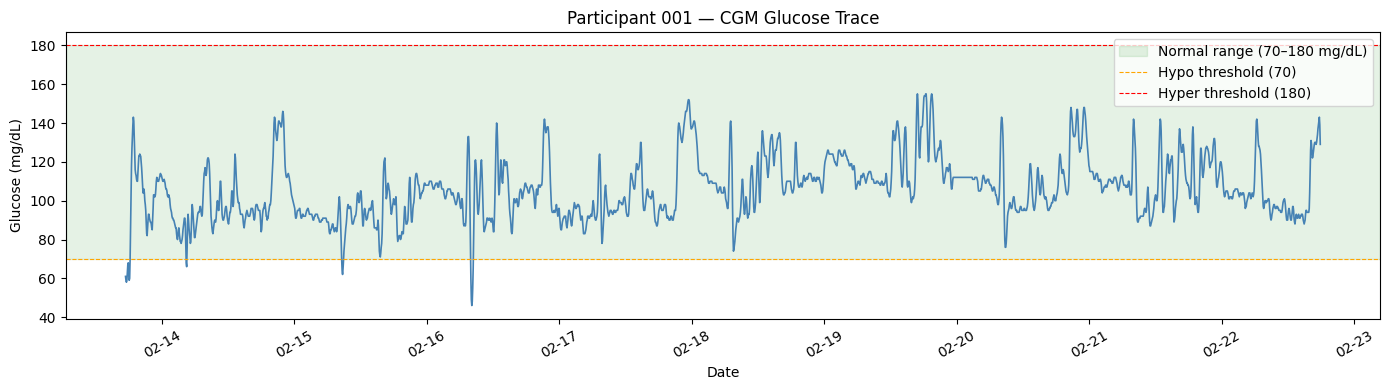

In [5]:
# ── Plot CGM trace ──
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cgm['datetime'], cgm['glucose'], color='steelblue', linewidth=1.2)
ax.axhspan(70, 180, alpha=0.1, color='green', label='Normal range (70–180 mg/dL)')
ax.axhline(70,  color='orange', linestyle='--', linewidth=0.8, label='Hypo threshold (70)')
ax.axhline(180, color='red',    linestyle='--', linewidth=0.8, label='Hyper threshold (180)')
ax.set_title(f'Participant {PARTICIPANT} — CGM Glucose Trace')
ax.set_ylabel('Glucose (mg/dL)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2B — Clean the IBI Data

**What is IBI artifact?**
IBI data from wrist wearables is noisy. Artifacts occur when:
- The device loses contact with the skin (movement)
- A beat is missed (the IBI appears double the normal value)
- A beat is double-detected (IBI appears half the normal value)

**Normal IBI range:** A healthy resting heart rate is 40–200 bpm,
which translates to IBI values of 0.3–1.5 seconds.
Anything outside this is almost certainly an artifact.

We also apply a **successive difference filter**: if two consecutive IBI values
differ by more than 20%, one of them is likely an artifact.

In [11]:
# ── Clean IBI ──

# Step 1: Parse and rename columns
ibi = ibi_raw.copy()
print("IBI columns before cleaning:", ibi.columns.tolist())
ibi.columns = ibi.columns.str.strip().str.lower().str.replace(' ', '_')
print("IBI columns after cleaning:", ibi.columns.tolist())

# Rename to standard names — adjust if your column names differ
# Expected: 'datetime' and 'ibi' (in seconds)
ibi = ibi.rename(columns={
    ibi.columns[0]: 'datetime',
    ibi.columns[1]: 'ibi'
})

ibi['datetime'] = pd.to_datetime(ibi['datetime'])
ibi = ibi.sort_values('datetime').reset_index(drop=True)

print(f"IBI shape before cleaning: {ibi.shape}")
print(f"IBI value range: {ibi['ibi'].min():.3f}s – {ibi['ibi'].max():.3f}s")

# Step 2: Remove physiologically impossible values
# 0.3s = 200 bpm (extreme athlete max), 1.5s = 40 bpm (deep sleep)
ibi_clean = ibi[(ibi['ibi'] >= 0.3) & (ibi['ibi'] <= 1.5)].copy()
print(f"After range filter (0.3–1.5s): {len(ibi_clean)} rows ({len(ibi)-len(ibi_clean)} removed)")

# Step 3: Successive difference artifact removal
# If consecutive IBI values differ by >20%, flag the second as suspect
ibi_clean['ibi_diff_pct'] = ibi_clean['ibi'].pct_change().abs()
artifact_mask = ibi_clean['ibi_diff_pct'] > 0.20
print(f"Successive difference artifacts (>20% change): {artifact_mask.sum()} rows")
ibi_clean = ibi_clean[~artifact_mask].drop(columns=['ibi_diff_pct'])

print(f"\nFinal IBI rows after cleaning: {len(ibi_clean)}")
print(f"Date range: {ibi_clean['datetime'].min()} → {ibi_clean['datetime'].max()}")

IBI columns before cleaning: ['datetime', ' ibi']
IBI columns after cleaning: ['datetime', 'ibi']
IBI shape before cleaning: (266366, 2)
IBI value range: 0.313s – 1.813s
After range filter (0.3–1.5s): 266357 rows (9 removed)
Successive difference artifacts (>20% change): 7526 rows

Final IBI rows after cleaning: 258831
Date range: 2020-02-13 15:33:22.059328 → 2020-02-22 17:51:35.691598


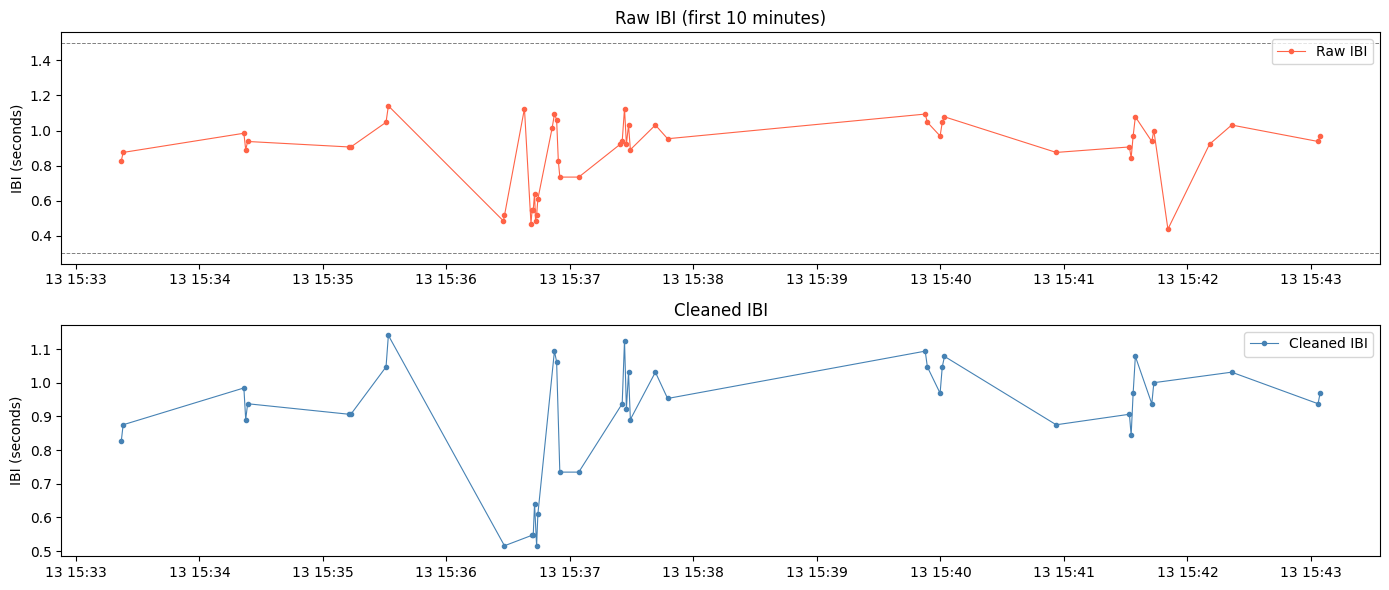

In [12]:
# ── Visualise raw vs cleaned IBI ──
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# Show a 10-minute sample for clarity
sample_end   = ibi['datetime'].iloc[0] + pd.Timedelta(minutes=10)
ibi_sample   = ibi[ibi['datetime'] <= sample_end]
clean_sample = ibi_clean[ibi_clean['datetime'] <= sample_end]

axes[0].plot(ibi_sample['datetime'], ibi_sample['ibi'], 'o-', markersize=3,
             color='tomato', linewidth=0.8, label='Raw IBI')
axes[0].axhline(0.3, color='gray', linestyle='--', linewidth=0.7)
axes[0].axhline(1.5, color='gray', linestyle='--', linewidth=0.7)
axes[0].set_ylabel('IBI (seconds)')
axes[0].set_title('Raw IBI (first 10 minutes)')
axes[0].legend()

axes[1].plot(clean_sample['datetime'], clean_sample['ibi'], 'o-', markersize=3,
             color='steelblue', linewidth=0.8, label='Cleaned IBI')
axes[1].set_ylabel('IBI (seconds)')
axes[1].set_title('Cleaned IBI')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 3 — IBI Windowing & HRV Feature Extraction

### Why Window the IBI Data?

A single IBI value (e.g. 0.828 seconds) tells you almost nothing useful.
But if you collect **all IBI values over a 5-minute window** (~300–400 beats),
you can compute statistics that describe the *variability pattern* of those beats.
That variability pattern — HRV — reflects your ANS state, which correlates with glucose.

### What are these HRV Metrics?

All of these are computed from the IBI values (in milliseconds = RR intervals) within one window:

| Metric | Full Name | What it measures |
|--------|-----------|------------------|
| **MeanNN** | Mean of NN intervals | Average time between beats = inverse of HR |
| **SDNN** | Standard Deviation of NN intervals | Overall HRV — total variability |
| **RMSSD** | Root Mean Square of Successive Differences | Short-term variability — parasympathetic (vagal) activity |
| **SDSD** | SD of Successive Differences | Very similar to RMSSD, captures beat-to-beat changes |
| **pNN50** | % of successive beats differing by >50ms | Parasympathetic activity (higher = more relaxed/rested) |
| **pNN20** | % of successive beats differing by >20ms | More sensitive version of pNN50 |
| **CVNN** | Coefficient of Variation of NN | SDNN/MeanNN — normalised variability |
| **CVSD** | Coefficient of Variation of SD | RMSSD/MeanNN — normalised short-term variability |
| **MadNN** | Mean Absolute Deviation of NN | Robust variability measure |
| **MedianNN** | Median NN interval | Robust central tendency |

**Key intuition for BGL:**
- High BGL (hyperglycaemia) → ANS dysregulation → often **lower** RMSSD, SDNN
- Low BGL (hypoglycaemia) → sympathetic activation → **higher** HR, **lower** HRV
- These relationships are the biological basis for HRV-based BGL prediction

### Window Strategy
For each CGM reading (every 5 minutes), we take the IBI values from the
**preceding W minutes** and compute HRV features from them.
This avoids data leakage — we only use data available **before** the glucose reading.

In [ ]:
def compute_hrv_from_window(ibi_window_seconds, min_beats=20):
    """
    Compute HRV time-domain features from a window of IBI values.

    Parameters:
    -----------
    ibi_window_seconds : array-like
        IBI values in SECONDS for one time window
    min_beats : int
        Minimum number of beats required to compute valid HRV.
        Windows with fewer beats are returned as NaN.

    Returns:
    --------
    dict of HRV metrics (or dict of NaNs if not enough beats)
    """
    # Define which metrics we want
    metric_names = [
        'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD',
        'HRV_CVNN',   'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN',
        'HRV_pNN50',  'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN',
        'HRV_IQRNN',  'HRV_SDRMSSD'
    ]
    nan_result = {m: np.nan for m in metric_names}

    ibi_arr = np.array(ibi_window_seconds)
    ibi_arr = ibi_arr[~np.isnan(ibi_arr)]  # remove any NaNs

    if len(ibi_arr) < min_beats:
        return nan_result

    # Convert seconds → milliseconds for neurokit2
    rri_ms = ibi_arr * 1000.0
    

    try:
        # NeuroKit2 computes all time-domain HRV metrics in one call
        # See this: https://github.com/neuropsychology/NeuroKit/issues/433
        # we didn't need to simulate peaks, just pass RRI directly to hrv_time with sampling_rate=1
        # see the method documentation: https://neuropsychology.github.io/NeuroKit/functions/hrv.html#hrv-time
        # hrv_df = nk.hrv_time(
        #     pd.DataFrame({'RRI': rri_ms}),
        #     sampling_rate=1  # we pass RRI directly, not raw signal
        # )
        # Alternative method, both gives the same results
        # See this: https://github.com/neuropsychology/NeuroKit/issues/433
        peaks_ms = np.append([0], np.cumsum(rri_ms))  # simulate peak times in ms
        print(f"RRI raw(ms): {rri_ms[:5]}...{rri_ms[:5]}\nPeaks (ms): {peaks_ms[:5]} ... {peaks_ms[-5:]}")  # debug print
        hrv_df = nk.hrv_time(peaks_ms, sampling_rate=1000)
        result = {}
        for m in metric_names:
            result[m] = hrv_df[m].iloc[0] if m in hrv_df.columns else np.nan
        return result
    except Exception as e:
        print(f"Error computing HRV for window with {len(ibi_arr)} beats: {e}")

        return nan_result


# ── Quick sanity test ──
test_ibi = ibi_clean['ibi'].values[:100]  # first 100 beats
test_hrv = compute_hrv_from_window(test_ibi)
print("Sample HRV output for first 100 IBI values:")
for k, v in test_hrv.items():
    print(f"  {k:<20}: {v:.4f}" if not np.isnan(v) else f"  {k:<20}: NaN")

RRI raw(ms): [828.163 875.04  984.42  890.666 937.543]...[828.163 875.04  984.42  890.666 937.543]
Peaks (ms): [   0.     828.163 1703.203 2687.623 3578.289] ... [89863.487 91082.293 91910.456 92863.625 93738.665]
Sample HRV output for first 100 IBI values:
  HRV_MeanNN          : 937.3866
  HRV_SDNN            : 151.3421
  HRV_RMSSD           : 161.4962
  HRV_SDSD            : 162.3174
  HRV_CVNN            : 0.1615
  HRV_CVSD            : 0.1723
  HRV_MedianNN        : 953.1690
  HRV_MadNN           : 115.8326
  HRV_pNN50           : 67.0000
  HRV_pNN20           : 89.0000
  HRV_MinNN           : 515.6490
  HRV_MaxNN           : 1281.3090
  HRV_IQRNN           : 156.2570
  HRV_SDRMSSD         : 0.9371


In [32]:
# ── Build HRV feature windows aligned to CGM timestamps ──
#
# Strategy: for each CGM reading at time T,
# take IBI values from [T - WINDOW_MINUTES, T]
# and compute HRV features.
#
# WINDOW_MINUTES: experiment with 5, 10, 15, 30
#   5 min  = ~300-400 beats (matches CGM interval exactly)
#   10 min = more beats, more stable HRV estimates
#   15 min = standard clinical HRV window (best HRV validity)

WINDOW_MINUTES = 5   # ← try changing this
MIN_BEATS      = 20   # minimum beats in window for valid HRV

hrv_records = []

print(f"Computing HRV features with {WINDOW_MINUTES}-minute lookback windows...")
print(f"Processing {len(cgm)} CGM timestamps...")

for idx, row in cgm.iterrows():
    cgm_time  = row['datetime']
    window_start = cgm_time - pd.Timedelta(minutes=WINDOW_MINUTES)

    # Select IBI values that fall within the window BEFORE this CGM reading
    mask = (ibi_clean['datetime'] >= window_start) & (ibi_clean['datetime'] < cgm_time)
    ibi_window = ibi_clean.loc[mask, 'ibi'].values

    # Compute HRV features
    hrv_feats = compute_hrv_from_window(ibi_window, min_beats=MIN_BEATS)

    # Add metadata
    hrv_feats['datetime']     = cgm_time
    hrv_feats['glucose']      = row['glucose']
    hrv_feats['n_beats']      = len(ibi_window)
    hrv_feats['window_min']   = WINDOW_MINUTES
    hrv_records.append(hrv_feats)

# Assemble into DataFrame
df_hrv = pd.DataFrame(hrv_records)
df_hrv = df_hrv.sort_values('datetime').reset_index(drop=True)

print(f"\n✅ Done. HRV feature matrix shape: {df_hrv.shape}")
print(f"   Windows with valid HRV (≥{MIN_BEATS} beats): {df_hrv['HRV_SDNN'].notna().sum()}")
print(f"   Windows skipped (too few beats)           : {df_hrv['HRV_SDNN'].isna().sum()}")

Computing HRV features with 5-minute lookback windows...
Processing 2561 CGM timestamps...
RRI raw(ms): [781.286 703.157 765.66  750.034 765.66 ]...[781.286 703.157 765.66  750.034 765.66 ]
Peaks (ms): [   0.     781.286 1484.443 2250.103 3000.137] ... [121146.167 121864.95  122646.236 123474.399 124396.316]
RRI raw(ms): [765.66  781.286 812.537 906.291 812.537]...[765.66  781.286 812.537 906.291 812.537]
Peaks (ms): [   0.     765.66  1546.946 2359.483 3265.774] ... [136474.991 137193.774 137850.054 138506.334 139287.62 ]
RRI raw(ms): [640.654 656.28  687.531 609.403 687.531]...[640.654 656.28  687.531 609.403 687.531]
Peaks (ms): [   0.     640.654 1296.934 1984.465 2593.868] ... [153210.127 154053.916 154850.827 155663.364 156554.03 ]
RRI raw(ms): [906.291 750.034 859.414 828.163 859.414]...[906.291 750.034 859.414 828.163 859.414]
Peaks (ms): [   0.     906.291 1656.325 2515.739 3343.902] ... [55955.679 56674.462 57440.122 58315.162 59471.465]
RRI raw(ms): [750.034 859.414 890.666 

In [33]:
# ── Preview the feature matrix ──
print("Feature matrix preview:")
df_hrv.head(10)

Feature matrix preview:


,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_IQRNN,HRV_SDRMSSD,datetime,glucose,n_beats,window_min
0,846.233442,85.207628,93.656159,93.973586,0.100690,0.110674,843.7890,69.501323,57.142857,83.673469,593.777,1062.549,109.38000,0.909792,2020-02-13 17:23:32,61.0,147,5
1,740.891596,76.085014,80.108899,80.323914,0.102694,0.108125,734.4090,69.499840,55.851064,78.191489,578.151,953.169,93.75500,0.949770,2020-02-13 17:28:32,59.0,188,5
2,786.703668,111.772550,89.239350,89.456603,0.142077,0.113435,781.2860,115.834055,55.778894,78.894472,515.649,1109.426,171.88300,1.252503,2020-02-13 17:33:32,58.0,199,5
3,772.356688,80.135296,89.296405,89.828725,0.103754,0.115615,765.6600,69.499840,49.350649,80.519481,625.029,1156.303,78.12800,0.897408,2020-02-13 17:38:32,59.0,77,5
4,793.924147,99.789248,82.991464,83.616503,0.125691,0.104533,773.4730,104.250502,45.588235,72.058824,640.654,1078.174,160.16350,1.202404,2020-02-13 17:43:31,63.0,68,5
5,772.259665,97.059439,83.070171,83.328916,0.125682,0.107568,765.6600,115.834055,45.341615,77.018634,531.274,968.794,156.25700,1.168403,2020-02-13 17:48:31,67.0,161,5
6,783.157042,85.564970,83.065090,83.307381,0.109256,0.106064,781.2860,92.666948,48.502994,78.443114,625.029,1078.174,109.38000,1.030095,2020-02-13 17:53:31,68.0,167,5
7,749.074754,86.296657,87.285377,87.663175,0.115204,0.116524,742.2215,92.666948,45.614035,73.684211,562.526,1000.046,125.00600,0.988673,2020-02-13 17:58:31,63.0,114,5
8,803.747646,92.353317,81.640182,82.522120,0.114903,0.101574,796.9110,69.501323,39.583333,72.916667,656.280,1125.051,97.66125,1.131224,2020-02-13 18:03:32,59.0,48,5
9,795.237286,84.472373,82.790796,83.545989,0.106223,0.104108,781.2860,81.083394,57.142857,83.928571,656.280,984.420,125.00500,1.020311,2020-02-13 18:08:32,60.0,56,5


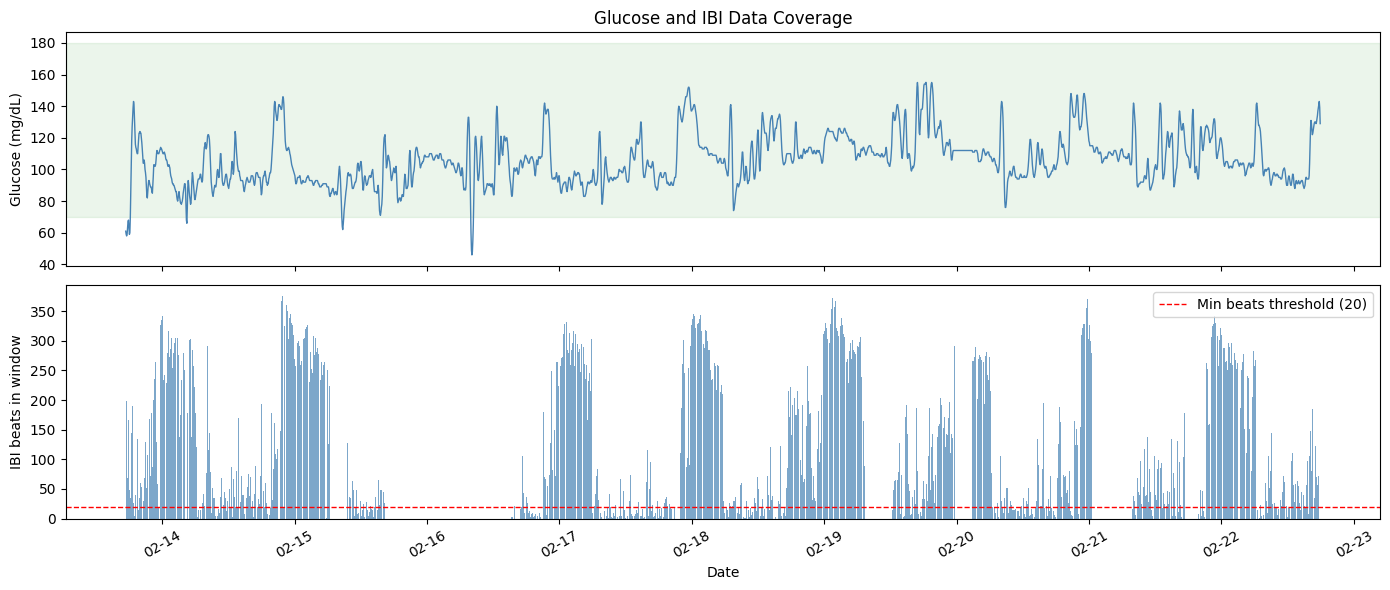

In [34]:
# ── Visualise beats-per-window over time ──
# This shows you where IBI data was sparse (device off wrist, movement artifacts)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df_hrv['datetime'], df_hrv['glucose'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].set_title('Glucose and IBI Data Coverage')
axes[0].axhspan(70, 180, alpha=0.08, color='green')

axes[1].bar(df_hrv['datetime'], df_hrv['n_beats'],
            width=0.003, color='steelblue', alpha=0.7)
axes[1].axhline(MIN_BEATS, color='red', linestyle='--',
                linewidth=1, label=f'Min beats threshold ({MIN_BEATS})')
axes[1].set_ylabel('IBI beats in window')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

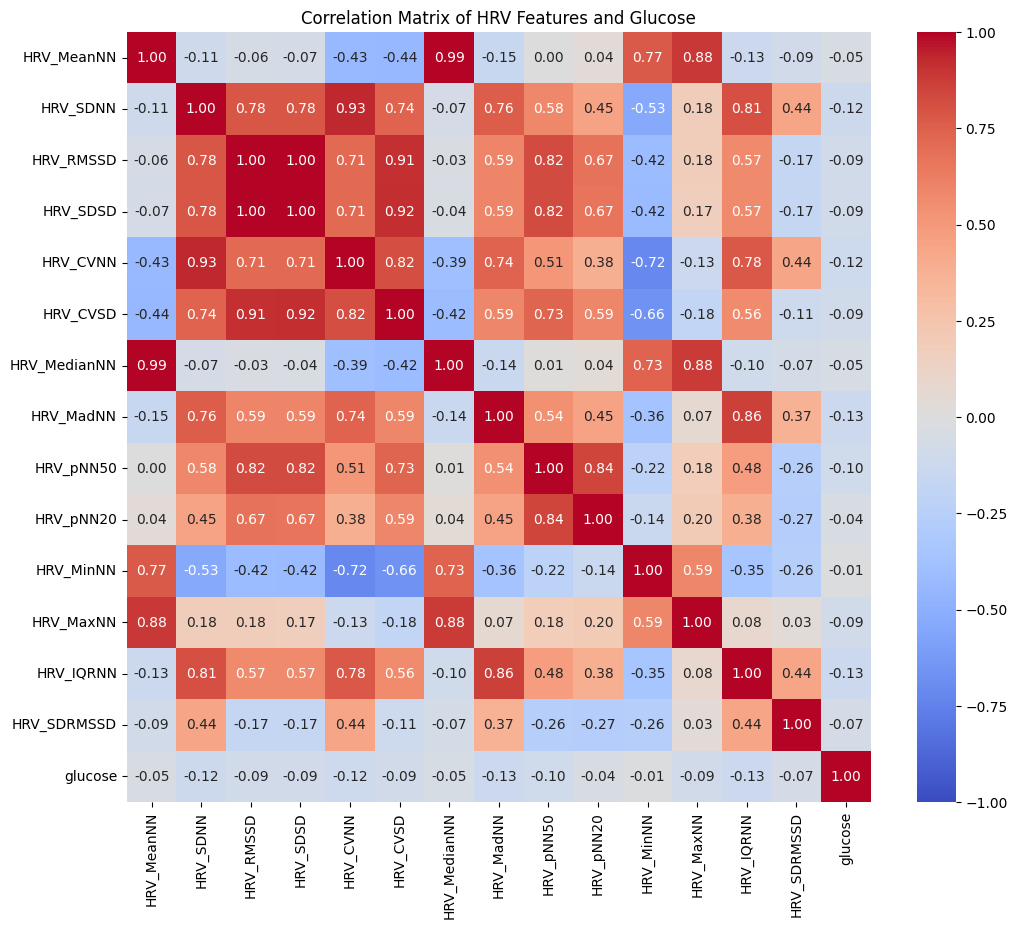

In [35]:
# ── Correlation matrix of HRV features and glucose ──
# Only include rows with valid HRV (non-NaN)
valid_hrv = df_hrv.dropna(subset=['HRV_SDNN'])  # using SDNN as a proxy for valid HRV rows
features = [col for col in df_hrv.columns if col.startswith('HRV_')]
corr_matrix = valid_hrv[features + ['glucose']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of HRV Features and Glucose')
plt.show()

---
## Step 4 — Feature Engineering

Beyond raw HRV metrics, we add:

1. **Time-of-day features** — Glucose has strong circadian patterns. The "dawn phenomenon"
   causes BGL to rise in the early morning (4–8am) due to cortisol.
   We encode time cyclically so the model knows 23:59 and 00:01 are close.

2. **Derived HRV ratios** — Some papers find that ratios between metrics are
   more informative than the raw metrics themselves.

3. **HRV lag features** — The previous window's HRV may carry predictive information
   (glucose changes are gradual, so recent HRV history matters).

In [85]:
def add_time_features(df):
    """
    Add cyclic time-of-day encoding.

    Why cyclic? Because 23:59 and 00:01 are only 2 minutes apart,
    but if we encode hour as 23 vs 0, the model thinks they're far apart.
    Sine/cosine encoding wraps time into a circle, fixing this.
    """
    seconds_in_day = 24 * 3600
    t = df['datetime'].dt.hour * 3600 + df['datetime'].dt.minute * 60 + df['datetime'].dt.second
    df['time_sin'] = np.sin(2 * np.pi * t / seconds_in_day)
    df['time_cos'] = np.cos(2 * np.pi * t / seconds_in_day)
    df['hour']     = df['datetime'].dt.hour     # also keep raw hour for interpretability
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
    df['is_dawn']  = ((df['hour'] >= 4)  & (df['hour'] <= 8)).astype(int)
    return df


def add_hrv_derived(df):
    """
    Add derived features from HRV metrics.
    MeanNN is in milliseconds → convert to HR in bpm.
    """
    # HR from MeanNN (MeanNN is in ms)
    df['HR_derived'] = 60000.0 / df['HRV_MeanNN'].replace(0, np.nan)

    # Ratio: RMSSD/SDNN — if close to 1, short-term variability dominates
    df['RMSSD_SDNN_ratio'] = df['HRV_RMSSD'] / df['HRV_SDNN'].replace(0, np.nan)

    # NN range = max - min (overall spread of IBI values in window)
    df['NN_range'] = df['HRV_MaxNN'] - df['HRV_MinNN']
    return df


def add_lag_features(df, hrv_cols, n_lags=3):
    """
    Add lagged HRV values from previous windows.

    lag=1 → HRV from 5 minutes ago
    lag=2 → HRV from 10 minutes ago
    lag=3 → HRV from 15 minutes ago

    This gives the model memory of recent physiological state.
    IMPORTANT: we only lag within the time-ordered data — no shuffling before this step.
    """
    for col in hrv_cols:
        for lag in range(1, n_lags + 1):
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
    return df

def add_rolling_features(df, hrv_cols, window_size=3):
    """
    Add rolling mean and std of HRV features over recent windows.

    This captures trends in HRV over time, e.g. if variability is increasing or decreasing.
    """
    for col in hrv_cols:
        df[f'{col}_roll_mean'] = df[col].rolling(window=window_size).mean()
        df[f'{col}_roll_std']  = df[col].rolling(window=window_size).std()
    return df


# ── Apply all feature engineering ──
df_feat = df_hrv.copy()
df_feat = add_time_features(df_feat)
df_feat = add_hrv_derived(df_feat)

# Select core HRV columns to lag
core_hrv = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_CVNN', 'HRV_pNN50']
df_feat = add_lag_features(df_feat, core_hrv, n_lags=3)
df_feat = add_rolling_features(df_feat, core_hrv, window_size=3)

print(f"Feature matrix shape after engineering: {df_feat.shape}")
print(f"\nAll features now available:")
print([c for c in df_feat.columns if c not in ['datetime', 'glucose', 'n_beats', 'window_min']])
with pd.option_context('display.max_columns', None):
    print(df_feat.head(10))

Feature matrix shape after engineering: (2561, 51)

All features now available:
['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'time_sin', 'time_cos', 'hour', 'is_night', 'is_dawn', 'HR_derived', 'RMSSD_SDNN_ratio', 'NN_range', 'HRV_MeanNN_lag1', 'HRV_MeanNN_lag2', 'HRV_MeanNN_lag3', 'HRV_SDNN_lag1', 'HRV_SDNN_lag2', 'HRV_SDNN_lag3', 'HRV_RMSSD_lag1', 'HRV_RMSSD_lag2', 'HRV_RMSSD_lag3', 'HRV_CVNN_lag1', 'HRV_CVNN_lag2', 'HRV_CVNN_lag3', 'HRV_pNN50_lag1', 'HRV_pNN50_lag2', 'HRV_pNN50_lag3', 'HRV_MeanNN_roll_mean', 'HRV_MeanNN_roll_std', 'HRV_SDNN_roll_mean', 'HRV_SDNN_roll_std', 'HRV_RMSSD_roll_mean', 'HRV_RMSSD_roll_std', 'HRV_CVNN_roll_mean', 'HRV_CVNN_roll_std', 'HRV_pNN50_roll_mean', 'HRV_pNN50_roll_std']
   HRV_MeanNN    HRV_SDNN  HRV_RMSSD   HRV_SDSD  HRV_CVNN  HRV_CVSD  \
0  846.233442   85.207628  93.656159  93.973586  0.100690  0.110674   
1 

---
## Step 5 — Prepare Modelling Dataset

### Handling Missing Values
After windowing and feature engineering, some rows will have NaN values because:
- The IBI window had too few beats (device off wrist)
- Lag features have NaN for the first N rows (no previous window to look back to)

We have two choices:
- **Drop rows** with too many NaNs (safest, simplest)
- **Impute** remaining NaNs with the column median (for isolated missing values)

We'll drop any row where the core HRV features are all missing,
then impute isolated NaNs in lag features.

In [96]:
# ── Define feature columns ──
# Everything except datetime, glucose (target), n_beats (metadata), window_min
EXCLUDE = ['datetime', 'glucose', 'n_beats', 'window_min']
FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE]

TARGET = 'glucose'

print(f"Input features ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

# ── Drop rows where ALL core HRV features are NaN (device was off) ──
core_check = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD']
all_nan_mask = df_feat[core_check].isnull().all(axis=1)
df_model = df_feat[~all_nan_mask].copy()
print(f"\nRows dropped (all core HRV NaN): {all_nan_mask.sum()}")
print(f"Rows remaining: {len(df_model)}")

# ── Impute only non-lag feature NaNs ──
lag_cols = [c for c in FEATURE_COLS if '_lag' in c]
rolling_cols = [c for c in FEATURE_COLS if '_roll_' in c]
imputable_cols = [c for c in FEATURE_COLS if c not in lag_cols and c not in rolling_cols]

nan_before = df_model[FEATURE_COLS].isnull().sum().sum()
df_model[imputable_cols] = df_model[imputable_cols].fillna(df_model[imputable_cols].mean())

# Drop rows that still have lag NaNs instead of imputing them
df_model = df_model.dropna(subset=lag_cols).copy()
df_model = df_model.dropna(subset=rolling_cols).copy()

nan_after = df_model[FEATURE_COLS].isnull().sum().sum()
print(f"NaN values imputed/dropped: {nan_before} → {nan_after}")


Input features (47):
['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'time_sin', 'time_cos', 'hour', 'is_night', 'is_dawn', 'HR_derived', 'RMSSD_SDNN_ratio', 'NN_range', 'HRV_MeanNN_lag1', 'HRV_MeanNN_lag2', 'HRV_MeanNN_lag3', 'HRV_SDNN_lag1', 'HRV_SDNN_lag2', 'HRV_SDNN_lag3', 'HRV_RMSSD_lag1', 'HRV_RMSSD_lag2', 'HRV_RMSSD_lag3', 'HRV_CVNN_lag1', 'HRV_CVNN_lag2', 'HRV_CVNN_lag3', 'HRV_pNN50_lag1', 'HRV_pNN50_lag2', 'HRV_pNN50_lag3', 'HRV_MeanNN_roll_mean', 'HRV_MeanNN_roll_std', 'HRV_SDNN_roll_mean', 'HRV_SDNN_roll_std', 'HRV_RMSSD_roll_mean', 'HRV_RMSSD_roll_std', 'HRV_CVNN_roll_mean', 'HRV_CVNN_roll_std', 'HRV_pNN50_roll_mean', 'HRV_pNN50_roll_std']

Rows dropped (all core HRV NaN): 1050
Rows remaining: 1511
NaN values imputed/dropped: 6920 → 0


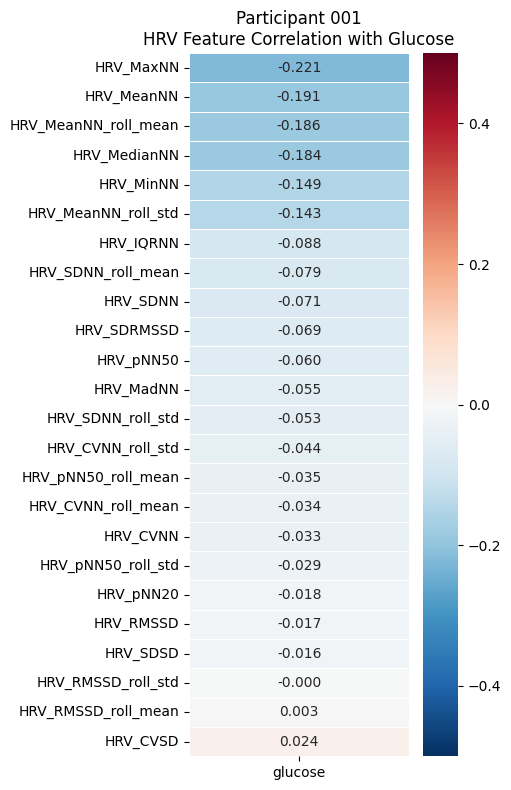


Top correlated HRV features with glucose:
HRV_MaxNN               0.220651
HRV_MeanNN              0.190571
HRV_MeanNN_roll_mean    0.186023
HRV_MedianNN            0.183841
HRV_MinNN               0.149226
HRV_MeanNN_roll_std     0.143233
HRV_IQRNN               0.088184
HRV_SDNN_roll_mean      0.079230
HRV_SDNN                0.070986
HRV_SDRMSSD             0.068741
Name: glucose, dtype: float64


In [97]:
# ── Correlation heatmap: HRV features vs glucose ──
# This tells you which HRV metrics are most related to BGL for this participant
hrv_only_cols = [c for c in FEATURE_COLS if 'HRV' in c and 'lag' not in c]
corr_data = df_model[hrv_only_cols + [TARGET]]
corr_matrix = corr_data.corr()[[TARGET]].drop(TARGET)

fig, ax = plt.subplots(figsize=(5, 8))
sns.heatmap(
    corr_matrix.sort_values(TARGET),
    annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5
)
ax.set_title(f'Participant {PARTICIPANT}\nHRV Feature Correlation with Glucose')
plt.tight_layout()
plt.show()

print("\nTop correlated HRV features with glucose:")
print(corr_matrix[TARGET].abs().sort_values(ascending=False).head(10))

---
## Step 6 — Time-Series Train/Validation Split

⚠️ **Critical Rule for Time-Series Data: Never Shuffle Before Splitting**

Why? Because glucose at time T is correlated with glucose at T-5min and T+5min.
If you shuffle and split randomly, future readings leak into training data.
Your model would appear to perform well in training but fail completely in the real world.

The correct approach: **train on earlier data, validate on later data.**
We use the first 80% of timepoints for training and the last 20% for validation.

In [98]:
# ── Time-series split ──
TEST_FRACTION = 0.20
split_idx = int(len(df_model) * (1 - TEST_FRACTION))

df_train = df_model.iloc[:split_idx].copy()
df_val   = df_model.iloc[split_idx:].copy()

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET]
X_val   = df_val[FEATURE_COLS]
y_val   = df_val[TARGET]

print(f"Train set: {len(X_train)} rows | {df_train['datetime'].min().date()} → {df_train['datetime'].max().date()}")
print(f"Val set  : {len(X_val)}   rows | {df_val['datetime'].min().date()} → {df_val['datetime'].max().date()}")
print(f"\nTrain glucose — mean: {y_train.mean():.1f}  std: {y_train.std():.1f} mg/dL")
print(f"Val   glucose — mean: {y_val.mean():.1f}  std: {y_val.std():.1f} mg/dL")

Train set: 862 rows | 2020-02-13 → 2020-02-20
Val set  : 216   rows | 2020-02-20 → 2020-02-22

Train glucose — mean: 109.5  std: 17.6 mg/dL
Val   glucose — mean: 109.4  std: 14.5 mg/dL


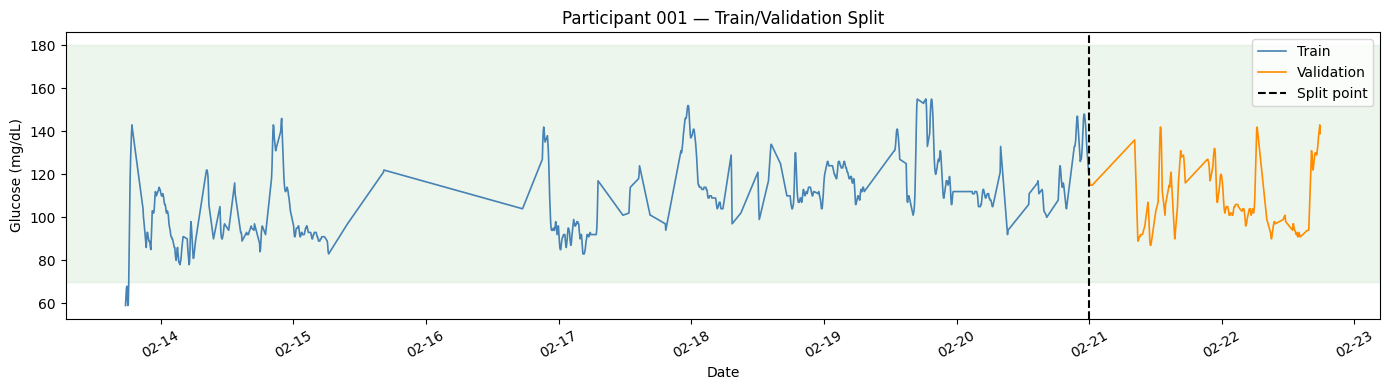

In [99]:
# ── Visualise the train/val split on the glucose trace ──
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train['datetime'], y_train, color='steelblue',  linewidth=1.2, label='Train')
ax.plot(df_val['datetime'],   y_val,   color='darkorange', linewidth=1.2, label='Validation')
ax.axvline(df_val['datetime'].iloc[0], color='black', linestyle='--', linewidth=1.5, label='Split point')
ax.axhspan(70, 180, alpha=0.07, color='green')
ax.set_title(f'Participant {PARTICIPANT} — Train/Validation Split')
ax.set_ylabel('Glucose (mg/dL)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## Step 7 — XGBoost Model Training

### Why XGBoost for this Task?
- Handles tabular HRV features very well (gradient boosted trees)
- Built-in regularization prevents overfitting on small physiological datasets
- Early stopping: we let the model train, but stop when validation performance
  stops improving — no need to manually tune `n_estimators`
- Feature importance is interpretable — useful for your FYP write-up

### Hyperparameter Explanation
| Parameter | What it does | Small FYP dataset tip |
|-----------|-------------|----------------------|
| `max_depth` | Tree depth — higher = more complex | Keep at 3–5, deeper = overfitting |
| `learning_rate` | Step size per tree | 0.05 is safe; lower = slower but generalises better |
| `subsample` | % of rows per tree | 0.8 = uses 80% of data per tree, reduces overfitting |
| `colsample_bytree` | % of features per tree | 0.8 = adds randomness, prevents memorisation |
| `min_child_weight` | Min samples in a leaf | Higher = simpler model, helps with small datasets |
| `reg_alpha/lambda` | L1/L2 regularisation | Non-zero values penalise complexity |

In [100]:
# ── Define XGBoost model ──
model = XGBRegressor(
    n_estimators        = 500,
    learning_rate       = 0.05,
    max_depth           = 3,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_weight    = 10,
    reg_alpha           = 0.5,
    reg_lambda          = 1.0,
    early_stopping_rounds = 30,
    eval_metric         = 'rmse',
    random_state        = RANDOM_STATE,
    verbosity           = 0,
    n_jobs              = -1,
)

# ── Train ──
model.fit(
    X_train, y_train,
    eval_set     = [(X_train, y_train), (X_val, y_val)],
    verbose      = 50  # print every 50 rounds
)

print(f"\n✅ Training complete.")
print(f"   Best iteration: {model.best_iteration}")
print(f"   Best val RMSE : {model.best_score:.4f} mg/dL")

[0]	validation_0-rmse:17.24457	validation_1-rmse:14.35270


[50]	validation_0-rmse:11.47987	validation_1-rmse:12.84174
[71]	validation_0-rmse:10.55097	validation_1-rmse:13.14728

✅ Training complete.
   Best iteration: 41
   Best val RMSE : 12.7916 mg/dL


---
## Step 8 — Prediction & Results

In [101]:
# ── Generate predictions ──
y_pred_train = model.predict(X_train)
y_pred_val   = model.predict(X_val)

print("Prediction range check:")
print(f"  Actual train glucose : {y_train.min():.1f} – {y_train.max():.1f} mg/dL")
print(f"  Predicted train glucose: {y_pred_train.min():.1f} – {y_pred_train.max():.1f} mg/dL")
print(f"  Actual val glucose   : {y_val.min():.1f} – {y_val.max():.1f} mg/dL")
print(f"  Predicted val glucose: {y_pred_val.min():.1f} – {y_pred_val.max():.1f} mg/dL")

Prediction range check:
  Actual train glucose : 59.0 – 155.0 mg/dL
  Predicted train glucose: 82.5 – 129.3 mg/dL
  Actual val glucose   : 87.0 – 143.0 mg/dL
  Predicted val glucose: 97.6 – 127.5 mg/dL


In [103]:
# ── Compute metrics ──
def evaluate(y_true, y_pred, label):
    """Compute and print regression metrics for BGL prediction."""
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    r2    = r2_score(y_true, y_pred)
    mard  = np.mean(np.abs(y_true - y_pred) / y_true) * 100  # Mean Absolute Relative Difference

    # Clinical accuracy
    errors   = np.abs(np.array(y_true) - y_pred)
    within_15pct = (errors / np.array(y_true) <= 0.15).mean() * 100  # FDA standard
    within_20pct = (errors / np.array(y_true) <= 0.20).mean() * 100

    print(f"\n{'='*50}")
    print(f" {label} Performance")
    print(f"{'='*50}")
    print(f"  MAE   : {mae:.3f} mg/dL")
    print(f"  RMSE  : {rmse:.3f} mg/dL")
    print(f"  R²    : {r2:.4f}")
    print(f"  MARD  : {mard:.2f}%")
    print(f"  Within ±15% (FDA CGM standard): {within_15pct:.1f}%")
    print(f"  Within ±20%                   : {within_20pct:.1f}%")

    return dict(mae=mae, rmse=rmse, r2=r2, mard=mard,
                within_15pct=within_15pct, within_20pct=within_20pct)

train_metrics = evaluate(y_train.values, y_pred_train, f'TRAIN — Participant {PARTICIPANT}')
val_metrics   = evaluate(y_val.values,   y_pred_val,   f'VALIDATION — Participant {PARTICIPANT}')


 TRAIN — Participant 001 Performance
  MAE   : 10.032 mg/dL
  RMSE  : 12.036 mg/dL
  R²    : 0.5310
  MARD  : 9.45%
  Within ±15% (FDA CGM standard): 83.6%
  Within ±20%                   : 92.9%

 VALIDATION — Participant 001 Performance
  MAE   : 9.783 mg/dL
  RMSE  : 12.792 mg/dL
  R²    : 0.2177
  MARD  : 8.97%
  Within ±15% (FDA CGM standard): 80.1%
  Within ±20%                   : 88.0%


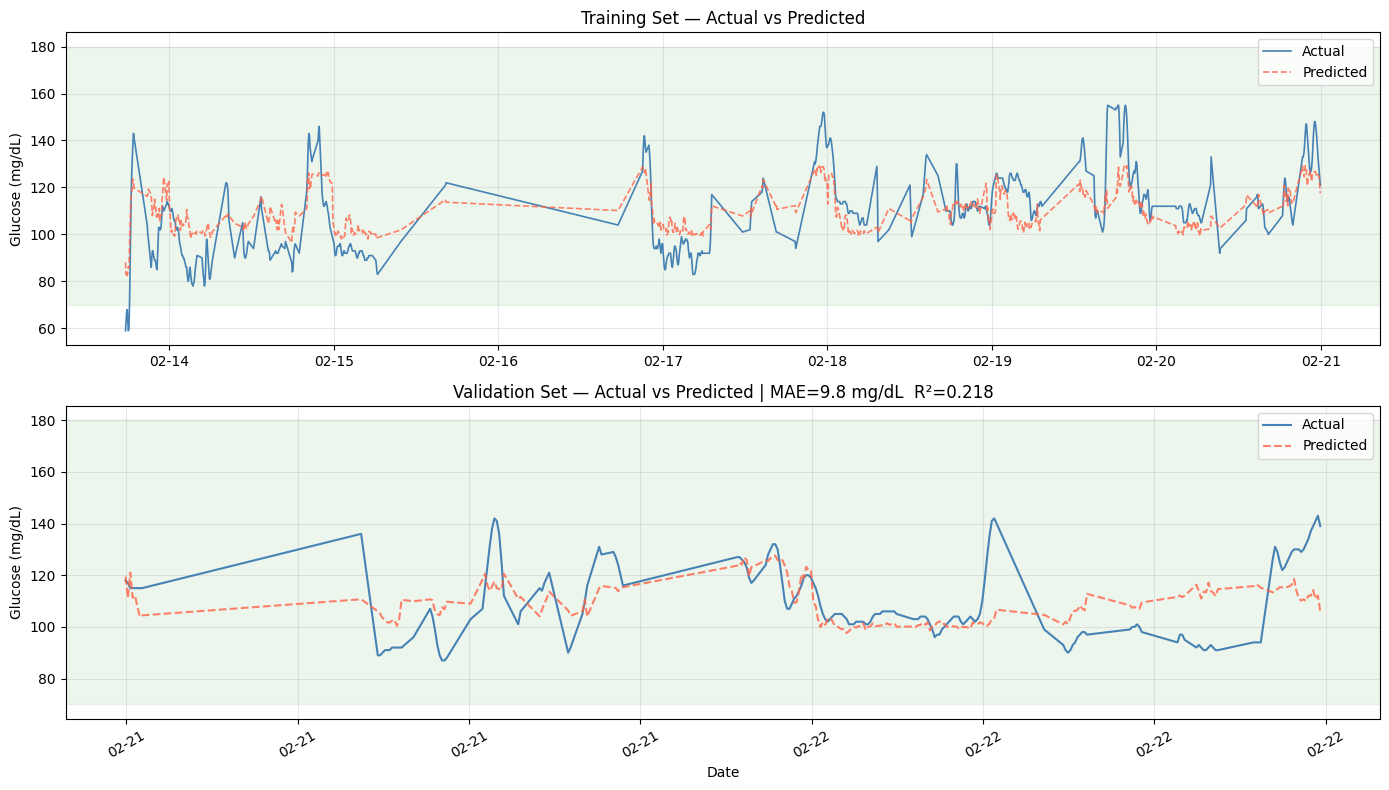

In [104]:
# ── Plot 1: Actual vs Predicted over time ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Train
axes[0].plot(df_train['datetime'], y_train.values, label='Actual',    color='steelblue', linewidth=1.2)
axes[0].plot(df_train['datetime'], y_pred_train,   label='Predicted', color='tomato',    linewidth=1.2, linestyle='--', alpha=0.8)
axes[0].axhspan(70, 180, alpha=0.07, color='green')
axes[0].set_title('Training Set — Actual vs Predicted')
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# Validation
axes[1].plot(df_val['datetime'], y_val.values,  label='Actual',    color='steelblue', linewidth=1.5)
axes[1].plot(df_val['datetime'], y_pred_val,    label='Predicted', color='tomato',    linewidth=1.5, linestyle='--', alpha=0.8)
axes[1].axhspan(70, 180, alpha=0.07, color='green')
axes[1].set_title(f'Validation Set — Actual vs Predicted | MAE={val_metrics["mae"]:.1f} mg/dL  R²={val_metrics["r2"]:.3f}')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

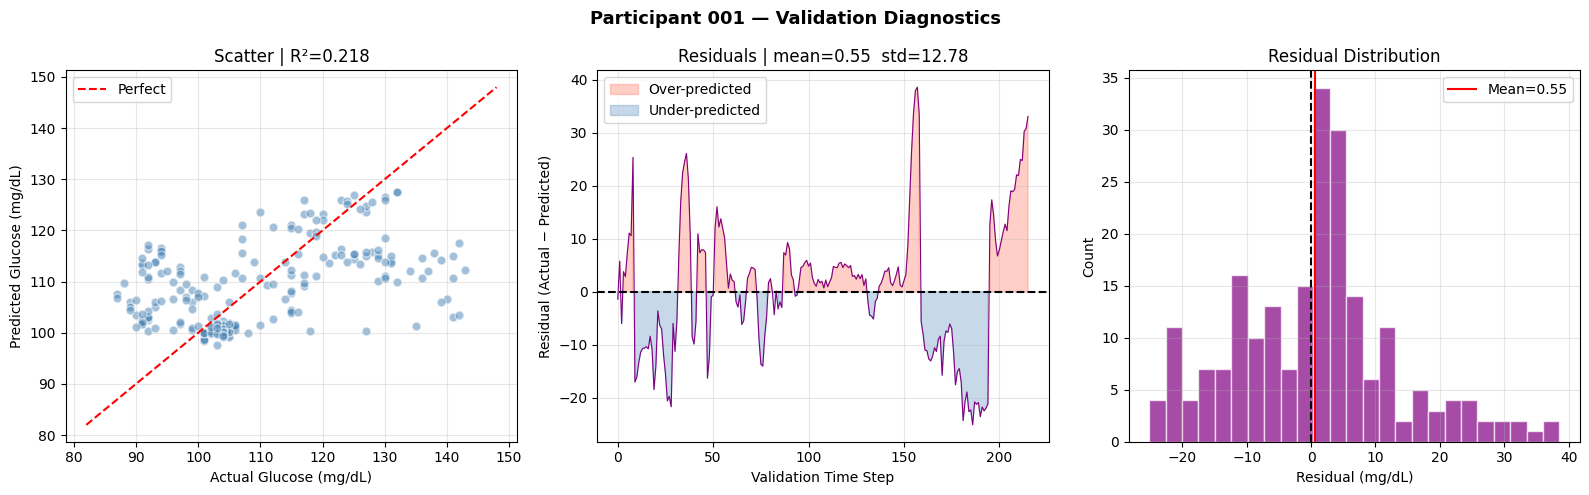

In [105]:
# ── Plot 2: Scatter + Residuals ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Participant {PARTICIPANT} — Validation Diagnostics', fontsize=13, fontweight='bold')

# Scatter
ax = axes[0]
ax.scatter(y_val, y_pred_val, alpha=0.5, color='steelblue', s=40, edgecolors='white')
lim = [min(y_val.min(), y_pred_val.min())-5, max(y_val.max(), y_pred_val.max())+5]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect')
ax.set_xlabel('Actual Glucose (mg/dL)')
ax.set_ylabel('Predicted Glucose (mg/dL)')
ax.set_title(f'Scatter | R²={val_metrics["r2"]:.3f}')
ax.legend(); ax.grid(alpha=0.3)

# Residuals over time
residuals = np.array(y_val.values) - y_pred_val
ax = axes[1]
ax.plot(range(len(residuals)), residuals, color='purple', linewidth=0.8)
ax.axhline(0, color='black', linestyle='--')
ax.fill_between(range(len(residuals)), residuals, 0,
                where=(residuals > 0), alpha=0.3, color='tomato',   label='Over-predicted')
ax.fill_between(range(len(residuals)), residuals, 0,
                where=(residuals < 0), alpha=0.3, color='steelblue', label='Under-predicted')
ax.set_xlabel('Validation Time Step')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title(f'Residuals | mean={residuals.mean():.2f}  std={residuals.std():.2f}')
ax.legend(); ax.grid(alpha=0.3)

# Histogram of residuals
ax = axes[2]
ax.hist(residuals, bins=25, color='purple', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', linestyle='--')
ax.axvline(residuals.mean(), color='red', linestyle='-', label=f'Mean={residuals.mean():.2f}')
ax.set_xlabel('Residual (mg/dL)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 9 — Feature Importance & Clinical Accuracy

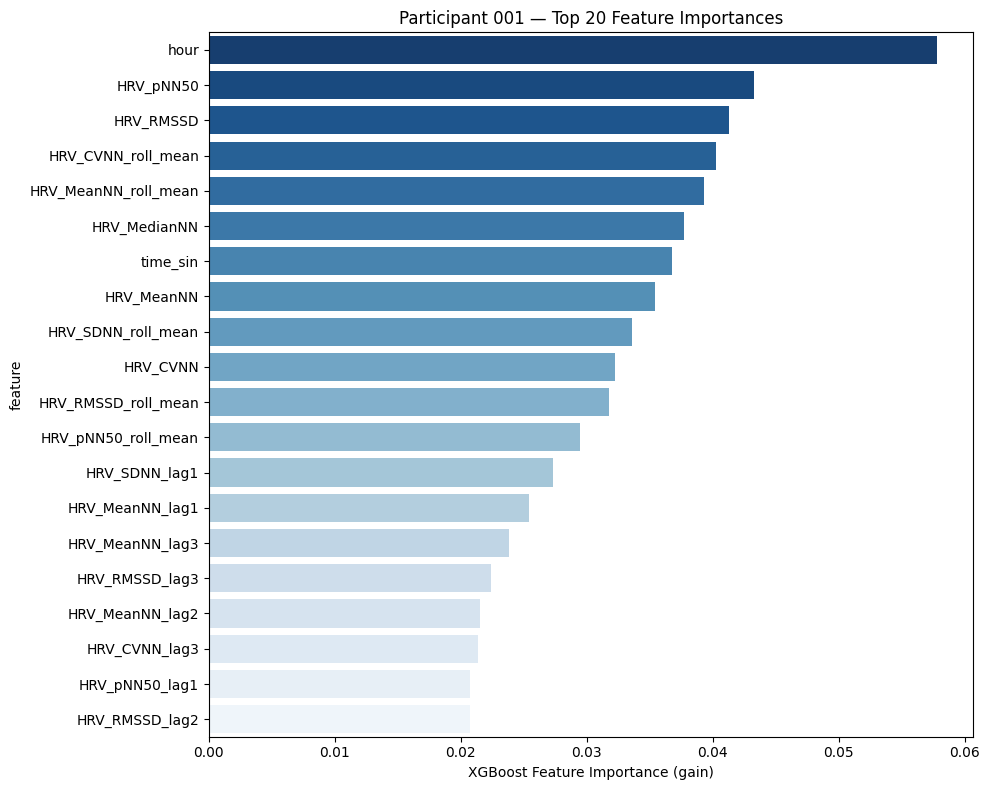


Top 10 most important features:
             feature  importance
                hour    0.057783
           HRV_pNN50    0.043239
           HRV_RMSSD    0.041288
  HRV_CVNN_roll_mean    0.040272
HRV_MeanNN_roll_mean    0.039330
        HRV_MedianNN    0.037688
            time_sin    0.036764
          HRV_MeanNN    0.035430
  HRV_SDNN_roll_mean    0.033585
            HRV_CVNN    0.032270


In [106]:
# ── Feature Importance ──
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(importance_df))
sns.barplot(
    data=importance_df.head(top_n),
    x='importance', y='feature',
    palette='Blues_r', ax=ax
)
ax.set_title(f'Participant {PARTICIPANT} — Top {top_n} Feature Importances')
ax.set_xlabel('XGBoost Feature Importance (gain)')
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features:")
print(importance_df.head(10).to_string(index=False))

In [107]:
# ── Clarke Error Grid (simplified) ──
# A standard clinical tool for BGL prediction evaluation
# Zone A = clinically accurate (<20% error)
# Zone B = acceptable (would not lead to incorrect treatment)
# Zone C/D/E = dangerous (could lead to wrong clinical action)

def simplified_clarke_zones(actual, predicted):
    zones = []
    for a, p in zip(actual, predicted):
        pct_error = abs(a - p) / max(a, 1e-6)
        if pct_error <= 0.20:
            zones.append('A')
        elif (a < 70 and p < 70) or (a > 180 and p > 180):
            zones.append('B')
        elif abs(a - p) <= 40:
            zones.append('B')
        else:
            zones.append('C/D/E')
    return np.array(zones)

zones = simplified_clarke_zones(y_val.values, y_pred_val)
print("\n=== Clarke Error Grid (Simplified) — Validation ===")
for z in ['A', 'B', 'C/D/E']:
    count = (zones == z).sum()
    pct   = (zones == z).mean() * 100
    label = {
        'A'     : 'Clinically accurate',
        'B'     : 'Acceptable',
        'C/D/E' : 'Potentially dangerous'
    }[z]
    print(f"  Zone {z} ({label}): {count:3d} readings ({pct:.1f}%)")

zone_ab_pct = ((zones == 'A') | (zones == 'B')).mean() * 100
print(f"\n  ✅ Zone A+B combined: {zone_ab_pct:.1f}% (target: >95%)")


=== Clarke Error Grid (Simplified) — Validation ===
  Zone A (Clinically accurate): 190 readings (88.0%)
  Zone B (Acceptable):  26 readings (12.0%)
  Zone C/D/E (Potentially dangerous):   0 readings (0.0%)

  ✅ Zone A+B combined: 100.0% (target: >95%)


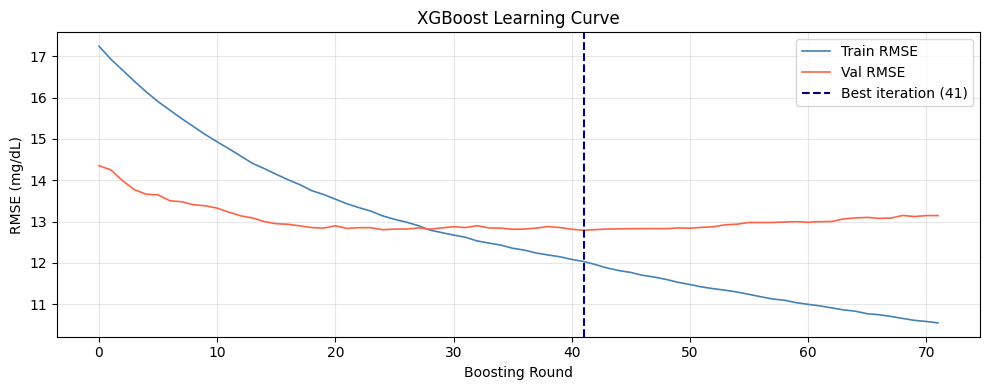


If val RMSE is much higher than train RMSE → overfitting.
If both are high → underfitting (features not predictive enough).


In [74]:
# ── Learning Curve ──
evals = model.evals_result()
train_rmse = evals['validation_0']['rmse']
val_rmse   = evals['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_rmse, label='Train RMSE', color='steelblue', linewidth=1.2)
ax.plot(val_rmse,   label='Val RMSE',   color='tomato',    linewidth=1.2)
ax.axvline(model.best_iteration, color='navy', linestyle='--',
           linewidth=1.5, label=f'Best iteration ({model.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE (mg/dL)')
ax.set_title('XGBoost Learning Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("\nIf val RMSE is much higher than train RMSE → overfitting.")
print("If both are high → underfitting (features not predictive enough).")

---
## Step 10 — Experiment Guide

Now that your baseline is running, here are experiments to try for your FYP:

### 🔬 Window Size Experiment
```python
# Re-run the windowing step with different WINDOW_MINUTES
for WINDOW_MINUTES in [5, 10, 15, 30]:
    # Re-run from Step 3 onwards
    # Record val MAE and R² for each
    # Plot: window size vs MAE
```

### 🔬 HRV Feature Subset Experiment
Compare model trained with:
- Only time-domain HRV (SDNN, RMSSD, pNN50...)
- Only derived features (HR_derived, RMSSD_SDNN_ratio...)
- Time features only (time_sin, time_cos, is_dawn...)
- All features combined

### 🔬 Lag Depth Experiment
```python
# Change n_lags in add_lag_features()
for n_lags in [0, 1, 3, 6, 12]:
    ...
```

### 🔬 Multi-Participant Comparison
```python
# Load all 16 participants, train one model per participant
for participant in ['001', '002', ..., '016']:
    # Run full pipeline
    # Store results[participant] = {mae, rmse, r2}
# Then compare: do some participants predict better than others? Why?
```

### 🔬 Global vs Personalized Model
Train one XGBoost on all participants combined and compare to individual models.
This is a key FYP comparison point — and the literature suggests personalized wins.

### 🔬 Add Frequency-Domain HRV (Advanced)
```python
# neurokit2 can also compute LF, HF, LF/HF ratio
hrv_freq = nk.hrv_frequency(pd.DataFrame({'RRI': rri_ms}), sampling_rate=1)
# LF/HF ratio reflects sympathetic/parasympathetic balance
```

---
## Summary: Your FYP Pipeline in One Picture

```
Wearable (E4 / Arduino + MAX30102)
         │
         ▼
    Raw IBI (seconds between heartbeats)
         │
    [Clean: remove artifacts]
         │
    [Window: group N minutes of IBI]
         │
    [HRV Feature Extraction]
    SDNN, RMSSD, pNN50, CVNN...
         │
    [Add time features + lags]
         │
         ▼
    XGBoost Regression
    (one model per participant)
         │
         ▼
    Predicted Blood Glucose (mg/dL)
```

This entire pipeline runs on a dataset you collected from a wearable — exactly what you'll build with Arduino + MAX30102. The IBI format will be identical.